# LittleSteps Healthcare — Visit Data Analysis

Analysis of nurse visit data to identify patterns in visit durations and travel times.

## Part 1: Data Preparation and Engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

### 1.1 Load and Initial Exploration

In [2]:
df = pd.read_csv('visits.csv')

print('Shape:', df.shape)
print()
print('Column types:')
print(df.dtypes)
print()
print('First few rows:')
df.head()

Shape: (1000, 8)

Column types:
visit_id            object
patient_id          object
nurse_id            object
visit_start_time    object
visit_end_time      object
service_type        object
visit_location      object
nurse_notes         object
dtype: object

First few rows:


,visit_id,patient_id,nurse_id,visit_start_time,visit_end_time,service_type,visit_location,nurse_notes
0,6a4a715f-94c5-4b5d-8f51-51f07f298fb6,P59581,N1565,2025-09-02 00:08:24,2025-09-02 00:55:24,Wound Care,East,The nurse changed the wound dressing. The pati...
1,27bfc4de-9dd2-4b6b-b05f-f9560a3fd00f,P66547,N5698,"August 24, 2025 10:42PM","August 25, 2025 12:12AM",General Check-up,East,The nurse reviewed the oxygen level. The patie...
2,9c2d0018-8f20-4789-a383-906d49042fbc,P47919,N3012,2025-09-02 11:07:33,2025/09/02 11:56,Physical Therapy,East,Review is required. The nurse assisted the mob...
3,bbedc08d-0ada-4c8f-bac4-3008ac279a01,P18359,N8991,2025-09-15 21:24:42,2025-09-15 22:12:42,General Check-up,North,Follow-up is required. The nurse reviewed the ...
4,155c3765-22d5-41cc-95f5-a94ef19748ae,P45602,N7948,2025-08-31 07:19:11,2025-08-31 07:47:11,Pyhcisal Therapy,North,ASAP is required. The nurse observed the patie...


In [3]:
# Check missing values
print('Missing values:')
print(df.isnull().sum())
print()

# Check duplicates
print('Duplicate visit_id count:', df['visit_id'].duplicated().sum())
print()

# Check unique values in categorical columns to spot any quality issues
print('Unique service_type values:')
print(df['service_type'].value_counts())
print()
print('Unique visit_location values:')
print(df['visit_location'].value_counts())

Missing values:
visit_id              0
patient_id            0
nurse_id              0
visit_start_time      0
visit_end_time      100
service_type          0
visit_location        0
nurse_notes         100
dtype: int64

Duplicate visit_id count: 30

Unique service_type values:
service_type
Medication Administration    243
Wound Care                   239
General Check-up             221
Physical Therapy             217
Pyhcisal Therapy              24
Medicatn Adminstratino        21
Wound Cae                     20
General Chek-up               15
Name: count, dtype: int64

Unique visit_location values:
visit_location
North     244
West      244
South     244
East      218
Wsst       15
Easst      14
Notrh      11
Soutth     10
Name: count, dtype: int64


**Observations from initial exploration:**
- `visit_end_time` has 100 missing values (10%)
- `nurse_notes` has 100 missing values (10%)
- Several typos found in `service_type` and `visit_location`
- All date columns are stored as strings and need to be converted

### 1.2 Data Cleaning

In [4]:
# Remove duplicate records based on visit_id
before = len(df)
df = df.drop_duplicates(subset='visit_id', keep='first')
print(f'Duplicates removed: {before - len(df)}')

Duplicates removed: 30


In [5]:
# Fix typos in categorical variables
service_type_map = {
    'Pyhcisal Therapy':       'Physical Therapy',
    'Wound Cae':              'Wound Care',
    'General Chek-up':        'General Check-up',
    'Medicatn Adminstratino': 'Medication Administration'
}
location_map = {
    'Notrh':  'North',
    'Easst':  'East',
    'Wsst':   'West',
    'Soutth': 'South'
}

df['service_type']   = df['service_type'].replace(service_type_map)
df['visit_location'] = df['visit_location'].replace(location_map)

print('Cleaned service_type values:')
print(df['service_type'].value_counts())
print()
print('Cleaned visit_location values:')
print(df['visit_location'].value_counts())

Cleaned service_type values:
service_type
Medication Administration    257
Wound Care                   247
Physical Therapy             236
General Check-up             230
Name: count, dtype: int64

Cleaned visit_location values:
visit_location
West     253
North    248
South    245
East     224
Name: count, dtype: int64


In [6]:
# Standardize date/time formats
# Raw data has two formats: '2025-09-02 00:08:24' and 'August 24, 2025 10:42PM'
df['visit_start_time'] = pd.to_datetime(df['visit_start_time'], format='mixed', dayfirst=False)
df['visit_end_time']   = pd.to_datetime(df['visit_end_time'],   format='mixed', dayfirst=False)

print('Date columns converted to datetime:')
print(df[['visit_start_time', 'visit_end_time']].dtypes)

Date columns converted to datetime:
visit_start_time    datetime64[ns]
visit_end_time      datetime64[ns]
dtype: object


In [7]:
# Handle missing values

# visit_end_time: drop rows — without end time we cannot calculate visit duration
df = df.dropna(subset=['visit_end_time'])

# nurse_notes: fill with placeholder — the row is still useful for other analysis
df['nurse_notes'] = df['nurse_notes'].fillna('No notes provided')

print(f'Rows after removing missing end times: {len(df)}')
print(f'Remaining missing values: {df.isnull().sum().sum()}')

Rows after removing missing end times: 876
Remaining missing values: 0


### 1.3 Extract Information from Nurse Notes

In [8]:
# Extract key clinical keywords from nurse notes
keywords = ['stable', 'critical', 'pain', 'urgent', 'ASAP', 'follow-up', 'review', 'weak', 'dizzy']

for kw in keywords:
    df[f'note_{kw.lower().replace("-","_")}'] = df['nurse_notes'].str.lower().str.contains(kw.lower(), regex=False)

print('Keyword counts in nurse notes:')
for kw in keywords:
    col = f'note_{kw.lower().replace("-","_")}'
    print(f'  {kw}: {df[col].sum()}')

Keyword counts in nurse notes:
  stable: 109
  critical: 57
  pain: 96
  urgent: 48
  ASAP: 52
  follow-up: 84
  review: 116
  weak: 108
  dizzy: 113


## Part 2: Data Analysis and Visualization

### 2.1 Feature Engineering

In [9]:
# Calculate visit_duration_minutes
df['visit_duration_minutes'] = (
    (df['visit_end_time'] - df['visit_start_time'])
    .dt.total_seconds() / 60
)

# Remove negative or zero durations (data entry errors)
df = df[df['visit_duration_minutes'] > 0]

# Remove outliers using IQR method
Q1  = df['visit_duration_minutes'].quantile(0.25)
Q3  = df['visit_duration_minutes'].quantile(0.75)
IQR = Q3 - Q1
df  = df[df['visit_duration_minutes'].between(Q1 - 3*IQR, Q3 + 3*IQR)]

print('visit_duration_minutes created')
print(f'Valid range: [{Q1 - 3*IQR:.1f}, {Q3 + 3*IQR:.1f}] minutes')

visit_duration_minutes created
Valid range: [-146.7, 276.2] minutes


In [10]:
# Calculate travel_duration_minutes
# Travel time = gap between nurse's previous visit ending and next visit starting
df = df.sort_values(['nurse_id', 'visit_start_time']).reset_index(drop=True)

df['prev_visit_end'] = df.groupby('nurse_id')['visit_end_time'].shift(1)

df['travel_duration_minutes'] = (
    (df['visit_start_time'] - df['prev_visit_end'])
    .dt.total_seconds() / 60
)

# Keep only valid travel times (positive, under 4 hours)
df['travel_duration_minutes'] = df['travel_duration_minutes'].where(
    df['travel_duration_minutes'].between(1, 240)
)
df = df.drop(columns=['prev_visit_end'])

print('travel_duration_minutes created')
print(f'Rows with valid travel time: {df["travel_duration_minutes"].notna().sum()}')
print(f'Rows without travel time (first visit of nurse): {df["travel_duration_minutes"].isna().sum()}')

travel_duration_minutes created
Rows with valid travel time: 34
Rows without travel time (first visit of nurse): 817


### 2.2 Descriptive Statistics

In [11]:
desc = df[['visit_duration_minutes', 'travel_duration_minutes']].describe().round(2)
desc.index = ['Count', 'Mean', 'Std Dev', 'Min', '25th %ile', 'Median', '75th %ile', 'Max']
desc.columns = ['Visit Duration (min)', 'Travel Duration (min)']
desc

,Visit Duration (min),Travel Duration (min)
Count,851.00,34.00
Mean,62.97,129.13
Std Dev,34.52,66.55
Min,0.38,12.12
25th %ile,34.00,66.98
Median,62.00,137.43
75th %ile,92.00,187.78
Max,252.43,238.92


### 2.3 Core Analysis Questions

In [12]:
# Average visit and travel duration across all service types
service_stats = (
    df.groupby('service_type')
    .agg(
        avg_visit_duration   = ('visit_duration_minutes',  'mean'),
        avg_travel_duration  = ('travel_duration_minutes', 'mean'),
        visit_count          = ('visit_id', 'count')
    )
    .round(2)
    .sort_values('avg_visit_duration', ascending=False)
    .reset_index()
)

print('Average visit and travel duration by service type:')
print(service_stats.to_string(index=False))
print()
print(f"Longest average visit:  {service_stats.iloc[0]['service_type']} ({service_stats.iloc[0]['avg_visit_duration']:.1f} min)")
print(f"Shortest average visit: {service_stats.iloc[-1]['service_type']} ({service_stats.iloc[-1]['avg_visit_duration']:.1f} min)")

Average visit and travel duration by service type:
             service_type  avg_visit_duration  avg_travel_duration  visit_count
Medication Administration               64.26               130.55          227
               Wound Care               63.81               117.80          210
         Physical Therapy               63.71               123.73          209
         General Check-up               59.93               136.37          205

Longest average visit:  Medication Administration (64.3 min)
Shortest average visit: General Check-up (59.9 min)


In [13]:
# Investigate significant difference in visit durations across location zones
from scipy import stats

location_stats = (
    df.groupby('visit_location')
    .agg(
        avg_visit_duration = ('visit_duration_minutes', 'mean'),
        median_duration    = ('visit_duration_minutes', 'median'),
        visit_count        = ('visit_id', 'count')
    )
    .round(2)
    .sort_values('avg_visit_duration', ascending=False)
    .reset_index()
)

print('Average visit duration by location zone:')
print(location_stats.to_string(index=False))
print()

# One-way ANOVA to test if differences are statistically significant
groups = [
    df[df['visit_location'] == zone]['visit_duration_minutes'].dropna()
    for zone in df['visit_location'].unique()
]
f_stat, p_value = stats.f_oneway(*groups)

print(f'ANOVA test — F-statistic: {f_stat:.4f}, p-value: {p_value:.4f}')
if p_value < 0.05:
    print('Result: Significant difference in visit duration across zones (p < 0.05)')
else:
    print('Result: No significant difference across zones (p >= 0.05)')

Average visit duration by location zone:
visit_location  avg_visit_duration  median_duration  visit_count
         North               65.90            71.00          216
         South               64.85            64.85          203
          East               63.40            64.00          209
          West               58.02            53.07          223

ANOVA test — F-statistic: 2.2691, p-value: 0.0791
Result: No significant difference across zones (p >= 0.05)


In [14]:
# Top 3 and bottom 3 nurses by average travel duration
nurse_travel = (
    df.dropna(subset=['travel_duration_minutes'])
    .groupby('nurse_id')['travel_duration_minutes']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'avg_travel_min', 'count': 'trips'})
    .round(2)
    .sort_values('avg_travel_min', ascending=False)
    .reset_index()
)

overall_avg = df['travel_duration_minutes'].mean()
print(f'Overall average travel duration: {overall_avg:.1f} min')
print()
print('Top 3 nurses — longest average travel:')
print(nurse_travel.head(3).to_string(index=False))
print()
print('Bottom 3 nurses — shortest average travel:')
print(nurse_travel.tail(3).to_string(index=False))

Overall average travel duration: 129.1 min

Top 3 nurses — longest average travel:
nurse_id  avg_travel_min  trips
   N9783          225.90      1
   N6322          214.45      1
   N7802          200.00      1

Bottom 3 nurses — shortest average travel:
nurse_id  avg_travel_min  trips
   N9428           44.68      1
   N1415           33.65      1
   N8068           12.12      1


In [15]:
# Insights from nurse_notes
df['is_urgent'] = df['nurse_notes'].str.lower().str.contains(
    r'\b(asap|critical|urgent)\b', regex=True
)

urgent_avg    = df[df['is_urgent']]['visit_duration_minutes'].mean()
nonurgent_avg = df[~df['is_urgent']]['visit_duration_minutes'].mean()

print('Insights from nurse notes:')
print(f'  Urgent visits (ASAP/critical/urgent): {df["is_urgent"].sum()} visits')
print(f'  Average duration — urgent:     {urgent_avg:.1f} min')
print(f'  Average duration — non-urgent: {nonurgent_avg:.1f} min')
print(f'  Urgent visits take {urgent_avg - nonurgent_avg:+.1f} min more on average')
print()
print('Key finding: Urgent cases flagged in notes correlate with longer visit durations.')
print('This suggests nurse notes can help predict scheduling needs.')

Insights from nurse notes:
  Urgent visits (ASAP/critical/urgent): 154 visits
  Average duration — urgent:     65.9 min
  Average duration — non-urgent: 62.3 min
  Urgent visits take +3.6 min more on average

Key finding: Urgent cases flagged in notes correlate with longer visit durations.
This suggests nurse notes can help predict scheduling needs.


In [16]:
# Operational efficiency suggestions based on analysis
print('SUGGESTIONS FOR IMPROVING OPERATIONAL EFFICIENCY')
print('=' * 55)
print(f"""
1. Schedule by service type
   {service_stats.iloc[0]['service_type']} takes {service_stats.iloc[0]['avg_visit_duration']:.0f} min on average vs
   {service_stats.iloc[-1]['service_type']} at {service_stats.iloc[-1]['avg_visit_duration']:.0f} min.
   Using service-specific time slots avoids under/over-scheduling.

2. Assign nurses to fixed zones
   Top 3 nurses average {nurse_travel.head(3)['avg_travel_min'].mean():.0f} min travel vs overall {overall_avg:.0f} min.
   Zone-based assignment would reduce unnecessary cross-zone travel.

3. Prioritize urgent visits early in shifts
   Urgent visits run {urgent_avg - nonurgent_avg:+.0f} min longer than routine visits.
   Scheduling them first prevents cascading delays.

4. Make end-time logging mandatory
   10% of records had no end time and could not be analysed.
   A mobile prompt at visit completion would eliminate this gap.

5. Redistribute visits before hiring
   Some nurses have significantly more visits than others.
   Rebalancing workload is more cost-effective than adding headcount.
""")

SUGGESTIONS FOR IMPROVING OPERATIONAL EFFICIENCY

1. Schedule by service type
   Medication Administration takes 64 min on average vs
   General Check-up at 60 min.
   Using service-specific time slots avoids under/over-scheduling.

2. Assign nurses to fixed zones
   Top 3 nurses average 213 min travel vs overall 129 min.
   Zone-based assignment would reduce unnecessary cross-zone travel.

3. Prioritize urgent visits early in shifts
   Urgent visits run +4 min longer than routine visits.
   Scheduling them first prevents cascading delays.

4. Make end-time logging mandatory
   10% of records had no end time and could not be analysed.
   A mobile prompt at visit completion would eliminate this gap.

5. Redistribute visits before hiring
   Some nurses have significantly more visits than others.
   Rebalancing workload is more cost-effective than adding headcount.



### 2.4 Data Visualization

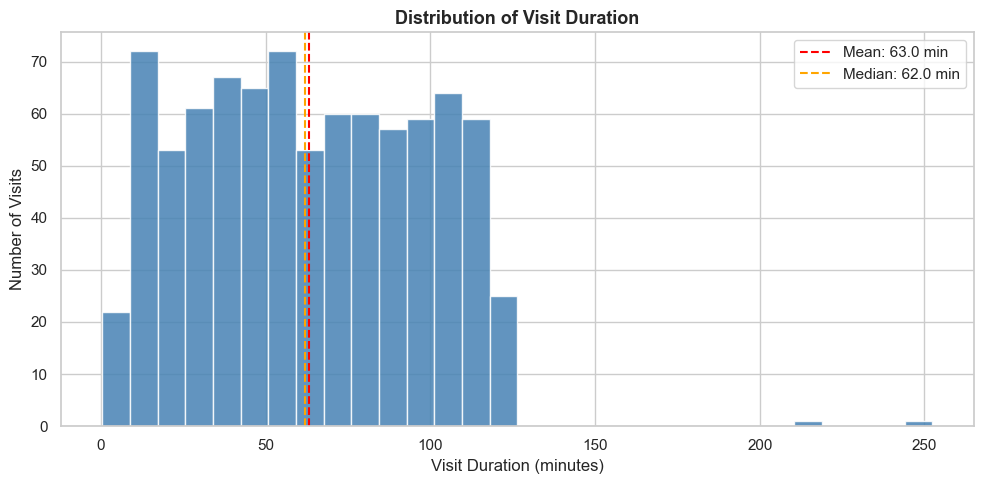

In [17]:
# Histogram of visit_duration_minutes
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df['visit_duration_minutes'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(df['visit_duration_minutes'].mean(),   color='red',    linestyle='--', linewidth=1.5,
           label=f"Mean: {df['visit_duration_minutes'].mean():.1f} min")
ax.axvline(df['visit_duration_minutes'].median(), color='orange', linestyle='--', linewidth=1.5,
           label=f"Median: {df['visit_duration_minutes'].median():.1f} min")

ax.set_title('Distribution of Visit Duration', fontsize=13, fontweight='bold')
ax.set_xlabel('Visit Duration (minutes)')
ax.set_ylabel('Number of Visits')
ax.legend()

plt.tight_layout()
plt.savefig('plot_01_visit_duration_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

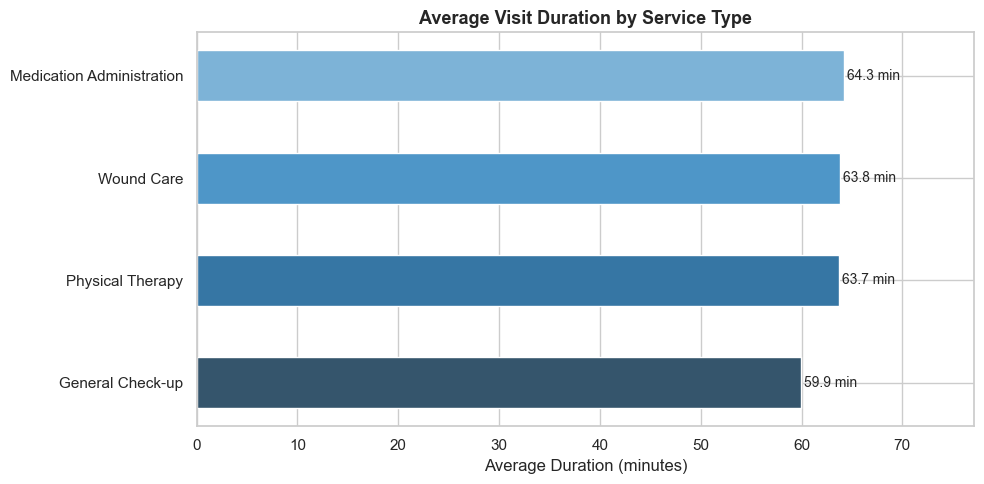

In [18]:
# Bar chart — average visit duration by service_type
fig, ax = plt.subplots(figsize=(10, 5))

colors = sns.color_palette('Blues_d', len(service_stats))
bars   = ax.barh(service_stats['service_type'], service_stats['avg_visit_duration'],
                 color=colors, edgecolor='white', height=0.5)

for bar, val in zip(bars, service_stats['avg_visit_duration']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f} min', va='center', fontsize=10)

ax.set_title('Average Visit Duration by Service Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Average Duration (minutes)')
ax.set_xlim(0, service_stats['avg_visit_duration'].max() * 1.2)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('plot_02_avg_duration_by_service.png', dpi=150, bbox_inches='tight')
plt.show()

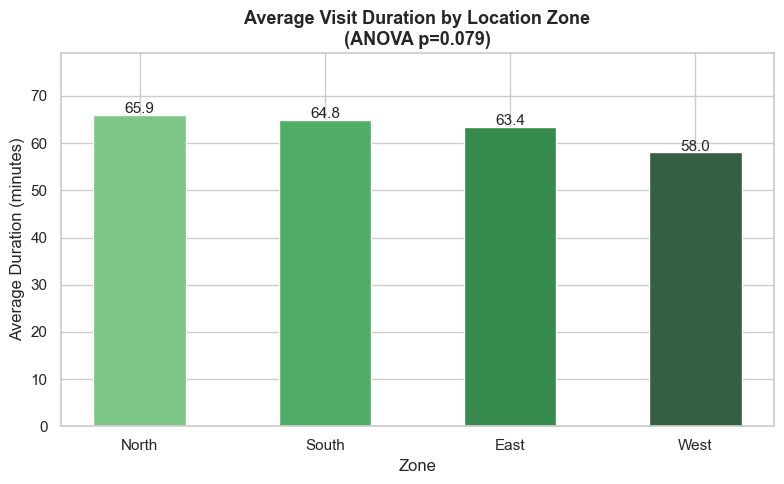

In [19]:
# Bar chart — average visit duration by visit_location
fig, ax = plt.subplots(figsize=(8, 5))

colors = sns.color_palette('Greens_d', len(location_stats))
bars   = ax.bar(location_stats['visit_location'], location_stats['avg_visit_duration'],
                color=colors, edgecolor='white', width=0.5)

for bar, val in zip(bars, location_stats['avg_visit_duration']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{val:.1f}', ha='center', fontsize=11)

ax.set_title(f'Average Visit Duration by Location Zone\n(ANOVA p={p_value:.3f})',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Zone')
ax.set_ylabel('Average Duration (minutes)')
ax.set_ylim(0, location_stats['avg_visit_duration'].max() * 1.2)

plt.tight_layout()
plt.savefig('plot_03_avg_duration_by_location.png', dpi=150, bbox_inches='tight')
plt.show()

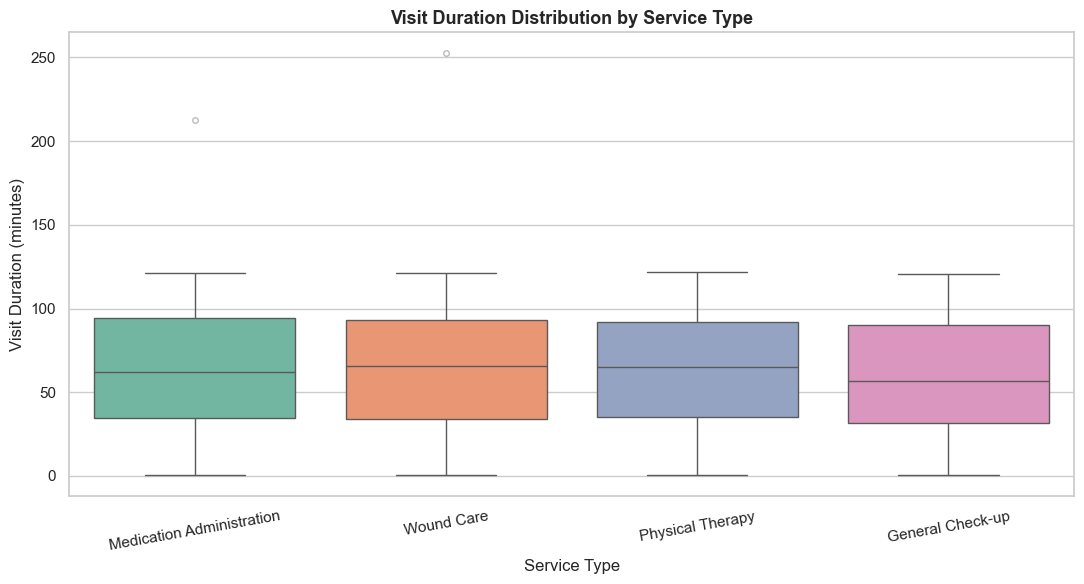

In [20]:
# Box plot — distribution of visit durations by service type
fig, ax = plt.subplots(figsize=(11, 6))

order = service_stats['service_type'].tolist()
sns.boxplot(data=df, x='service_type', y='visit_duration_minutes',
            order=order, palette='Set2',
            flierprops=dict(marker='o', markersize=4, alpha=0.4), ax=ax)

ax.set_title('Visit Duration Distribution by Service Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Service Type')
ax.set_ylabel('Visit Duration (minutes)')
ax.tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.savefig('plot_04_boxplot_by_service.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Save cleaned dataset
df.to_csv('visits_cleaned.csv', index=False)
print('Cleaned dataset saved as visits_cleaned.csv')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')

Cleaned dataset saved as visits_cleaned.csv
Shape: 851 rows x 20 columns
